In [1]:
import numpy as np
import matplotlib.pyplot as plt
from os import makedirs
import os.path as op
import torch

fig_dir = "./figures"

# Drive directory for saving figures
fig_dir = "/Users/acionca/Google Drive/My Drive/01-Work/01-EDEE/classes/year2/ArtificialLife/figures"
makedirs(fig_dir, exist_ok=True)

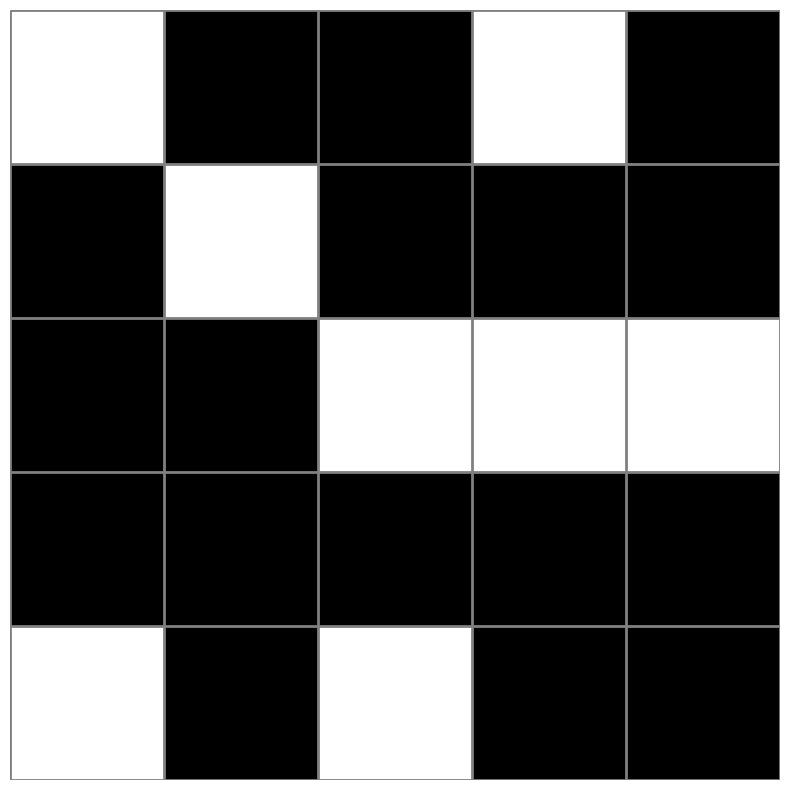

In [2]:
# Random CA map

np.random.seed(12)
random_map = np.random.randint(0, 3, (5, 5)) > 1

# Plot the random map
fig, axes = plt.subplots(figsize=(10, 10))

axes.imshow(random_map, cmap='gray', interpolation='nearest')

for i in range(random_map.shape[0]+1):
    axes.hlines(i - 0.5, -0.5, random_map.shape[1] - 0.5, color='gray', lw=2)
    axes.vlines(i - 0.5, -0.5, random_map.shape[1] - 0.5, color='gray', lw=2)
axes.axis('off')

fig.savefig(op.join(fig_dir, "random_CA.png"), bbox_inches='tight', dpi=300)

## 2D World

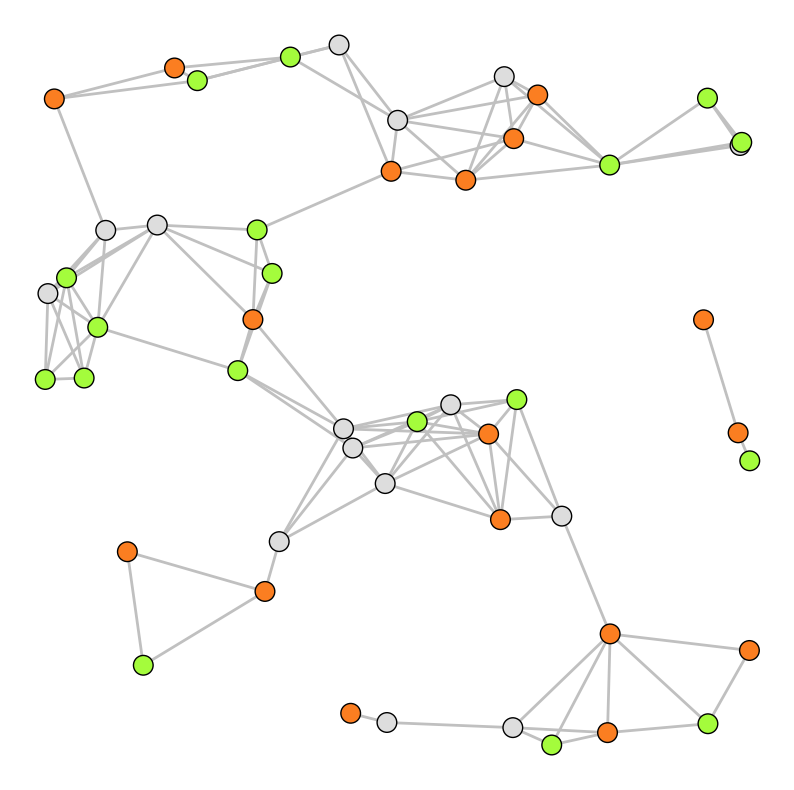

In [3]:
from matplotlib.colors import to_rgba

np.random.seed(12)

n_states = 2
pos = np.random.uniform(0, 10, (50, 2))
states = np.random.randint(0, n_states+1, (50, 1))

# Colors
cmap = plt.get_cmap("coolwarm", 3)
white_col = to_rgba(cmap(1)[:3], alpha=1)

cmap = plt.get_cmap("turbo", n_states + 3)
color_array = np.stack([white_col] + [to_rgba(cmap(i+1)[:3], 1) for i in range(1, n_states+1)], axis=0)

custom_cmap = plt.cm.colors.ListedColormap(color_array)

# Plot the random points
fig, axes = plt.subplots(figsize=(10, 10))
axes.scatter(pos[:, 0], pos[:, 1], s=200, c=states, cmap=custom_cmap, vmin=0, vmax=2, edgecolors="k")

# Plot the neighbor lines
for i in range(pos.shape[0]):
    for j in range(i + 1, pos.shape[0]):
        if np.linalg.norm(pos[i] - pos[j]) < 2:
            axes.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], color='silver', lw=2, zorder=0)

axes.axis('off')
fig.savefig(op.join(fig_dir, "random_graph.png"), bbox_inches='tight', dpi=300)

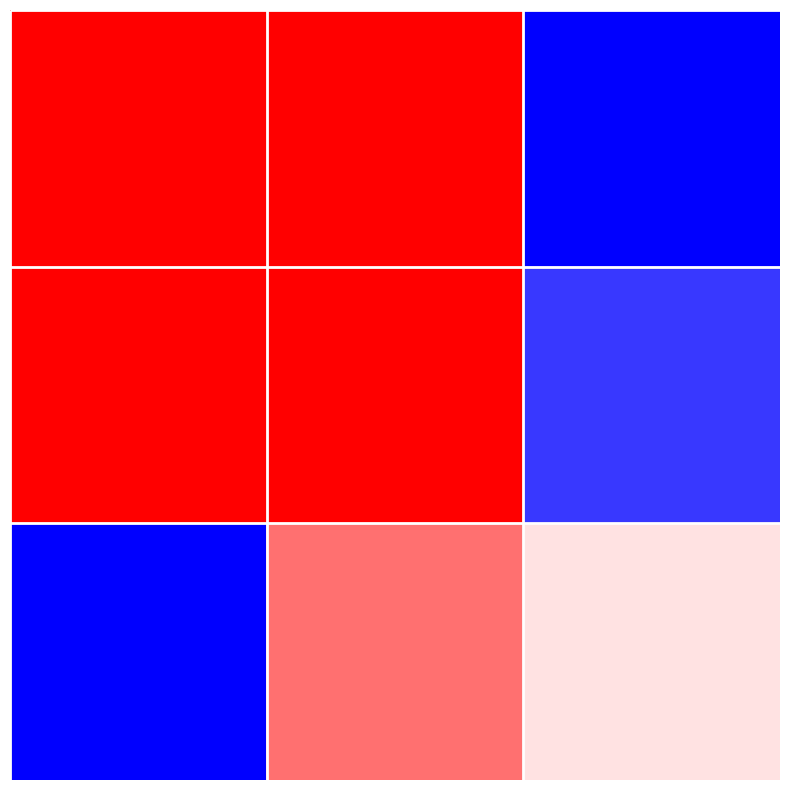

In [29]:
force_mat = torch.tensor([[ 1.0,  1.0, -0.8],
                          [ 1.0,  1.0, -0.6],
                          [-0.8,  0.6,  0.2]])

fig, axes = plt.subplots(figsize=(10, 10))
axes.imshow(force_mat, cmap='bwr', interpolation='nearest')

for i in range(force_mat.shape[0]):
    axes.hlines(i - 0.5, -0.5, force_mat.shape[1] - 0.5, color='w', lw=2)
    axes.vlines(i - 0.5, -0.5, force_mat.shape[1] - 0.5, color='w', lw=2)

axes.axis('off')
fig.savefig(op.join(fig_dir, "force_mat.png"), bbox_inches='tight', dpi=300)

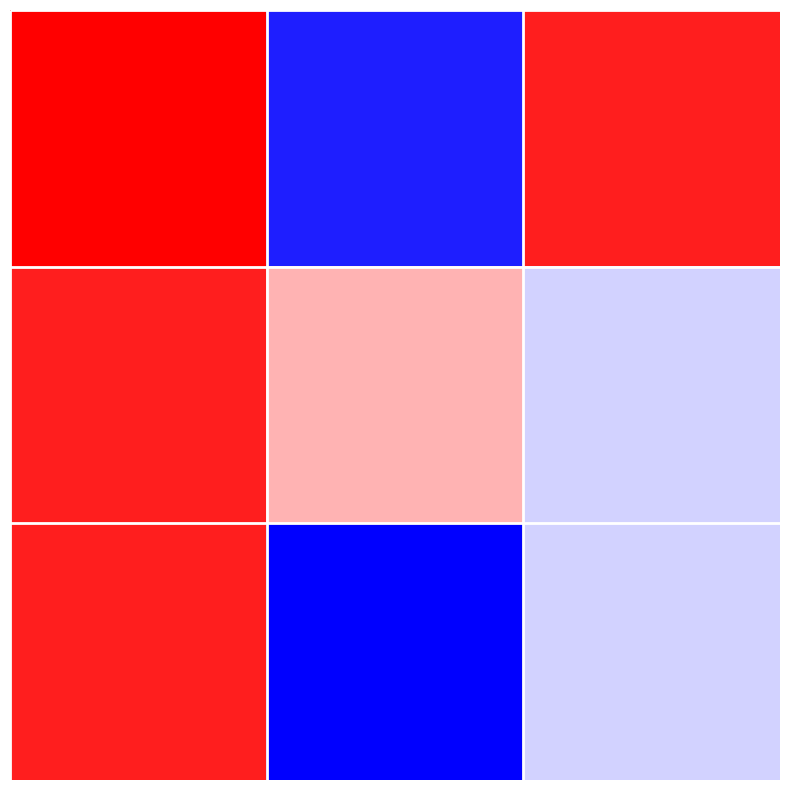

In [ ]:
force_mat = torch.tensor([[ 1.0, -0.8,  0.7],
                          [ 0.7,  1.0, -0.2],
                          [ 0.7, -0.9, -0.2]])

force_mat = torch.tensor([[ 0.8, -0.8, 0.7],
                          [ 0.7,  0.2, -0.2],
                          [ 0.7, -0.9, -0.2]])

fig, axes = plt.subplots(figsize=(10, 10))
axes.imshow(force_mat, cmap='bwr', interpolation='nearest')

for i in range(force_mat.shape[0]):
    axes.hlines(i - 0.5, -0.5, force_mat.shape[1] - 0.5, color='w', lw=2)
    axes.vlines(i - 0.5, -0.5, force_mat.shape[1] - 0.5, color='w', lw=2)

axes.axis('off')
fig.savefig(op.join(fig_dir, "force_mat_PartSlide.png"), bbox_inches='tight', dpi=300)

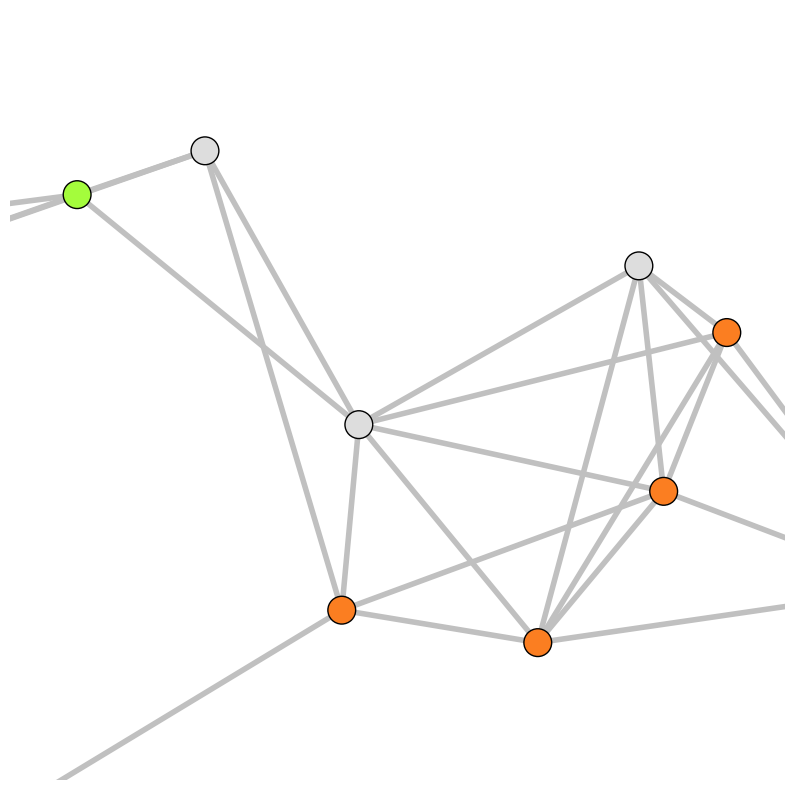

In [15]:
from matplotlib.colors import to_rgba

np.random.seed(12)

n_states = 2
pos = np.random.uniform(0, 10, (50, 2))
states = np.random.randint(0, n_states+1, (50, 1))

# Colors
cmap = plt.get_cmap("coolwarm", 3)
white_col = to_rgba(cmap(1)[:3], alpha=1)

cmap = plt.get_cmap("turbo", n_states + 3)
color_array = np.stack([white_col] + [to_rgba(cmap(i+1)[:3], 1) for i in range(1, n_states+1)], axis=0)

custom_cmap = plt.cm.colors.ListedColormap(color_array)

# Plot the random points
fig, axes = plt.subplots(figsize=(10, 10))
axes.scatter(pos[:, 0], pos[:, 1], s=400, c=states, cmap=custom_cmap, vmin=0, vmax=2, edgecolors="k")

# Plot the neighbor lines
for i in range(pos.shape[0]):
    for j in range(i + 1, pos.shape[0]):
        if np.linalg.norm(pos[i] - pos[j]) < 2:
            axes.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], color='silver', lw=4, zorder=0)

axes.set_xlim(3, 7)
axes.set_ylim(7.5, 10.5)
axes.axis('off')
fig.savefig(op.join(fig_dir, "random_graph_ZOOM.png"), bbox_inches='tight', dpi=300)

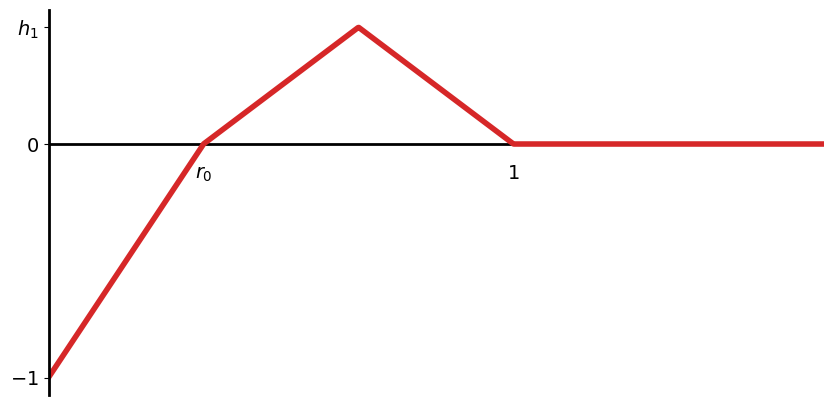

In [5]:
def linear_force(dist, r0: int=2, h0: int=1, r_factor: int=1, h1: int=1):

        f_out = np.zeros_like(dist)

        r1 = (1 + r_factor) * r0
        r2 = (1 + 2 * r_factor) * r0

        # Masks
        sub_r0 = dist < r0
        sub_r1 = (dist >= r0) & (dist < r1)
        sub_r2 = (dist >= r1) & (dist < r2)

        # Apply forces based on distance
        f_out[sub_r0] = (dist[sub_r0] - r0) * (h0 / r0)
        f_out[sub_r1] = (dist[sub_r1] - r0) * (h1 / (r0))# * r_factor))
        f_out[sub_r2] = -(dist[sub_r2] - r2) * (h1 / (r0))# * r_factor))

        return f_out

fig, axes = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 10, 1000)

r0 = 2
r_factor = 1

axes.hlines(0, -0.2, 10, lw=2, color='k')
# axes.vlines(0, -2.5, 1.5, lw=2, color='k')

# axes.vlines(r0, -1, 0, lw=2, color='gray', ls='--')

# axes.vlines(r0*(1+r_factor), -1, 0, lw=2, color='gray', ls='--')
# axes.vlines(r0*(1+2*r_factor), -1, 0, lw=2, color='gray', ls='--')

axes.text(r0, -0.3, f"$r_0$", fontsize=14, ha='center')
# axes.text(r0*(1+r_factor), -0.8, f"$r_0 (1 + r_{{factor}})$", fontsize=14, ha='center')
# axes.text(r0*(1+2*r_factor), -0.3, f"$r_0 (1 + 2r_{{factor}})$", fontsize=14, ha='center')
axes.text(r0*(1+2*r_factor), -0.3, f"$1$", fontsize=14, ha='center')

axes.plot(x, linear_force(x, r0=r0, h0=2, r_factor=r_factor, h1=1), color="tab:red",
          label=f"r0={r0}, r_factor=1, h1=1", lw=4)

axes.spines[:].set_linewidth(2)
axes.spines[['top', 'right', 'bottom']].set_visible(False)

axes.set_xticks([])
axes.set_yticks([-2, 0, 1], labels=["$-1$", "0", "$h_1$"], fontsize=14)

axes.set_xlim(0, 10)
# axes.axis("off")
fig.savefig(op.join(fig_dir, "force_shape.png"), bbox_inches='tight', dpi=300)

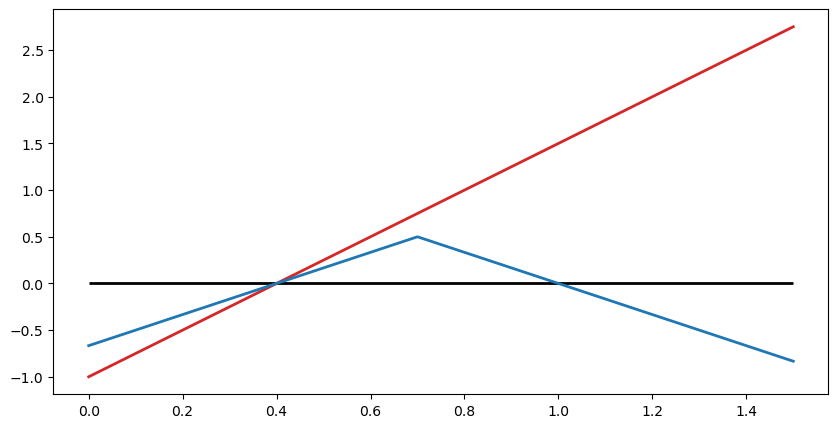

In [161]:
fig, axes = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 1.5, 1000)

axes.hlines(0, 0, 1.5, lw=2, color='k')

r0 = 0.4
h1 = 0.5

axes.plot(x, x/r0 - 1, color="tab:red", lw=2)
axes.plot(x, h1 * (1 - np.abs(2*x - 1 - r0)/(1-r0)), lw=2)

In [ ]:
import pygame
import cv2
import numpy as np

# Setup
width, height = 800, 600
screen = pygame.display.set_mode((width, height))
clock = pygame.time.Clock()
fps = 30

# Setup video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use 'XVID' or 'avc1' if mp4 fails
video_writer = cv2.VideoWriter("output.mp4", fourcc, fps, (width, height))

running = True
frame_count = 0

while running:
    screen.fill((0, 0, 0))  # Clear screen

    # --- Draw things ---
    pygame.draw.circle(screen, (255, 0, 0), (400, 300), 50)

    # --- Event handling ---
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # --- Capture the screen ---
    frame = pygame.surfarray.array3d(screen)
    frame = np.rot90(frame, 3)  # Rotate to match correct orientation
    frame = np.fliplr(frame)    # Flip horizontally
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR

    video_writer.write(frame)  # Write frame to video
    frame_count += 1

    pygame.display.flip()
    clock.tick(fps)

video_writer.release()
pygame.quit()
print(f"Saved {frame_count} frames to output.mp4")
